<a href="https://colab.research.google.com/github/Aadii0916/Proj1/blob/main/proj2/proj1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('netflix_titles.csv')


In [ ]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.isna()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
columns_to_fill = ['director', 'cast','country']
df[columns_to_fill] = df[columns_to_fill].fillna('Unknown')

In [ ]:
df = df.dropna(subset=['date_added'])

In [ ]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
dtype: int64


In [ ]:
df = df.reset_index(drop=True)

What is the breakdown of Movies vs. TV Shows?

In [ ]:
print("Breakdown of Content Type:")
type_counts = df['type'].value_counts()
print(type_counts)
print("\n")

Breakdown of Content Type:
type
Movie      6131
TV Show    2666
Name: count, dtype: int64




What are the top 5 countries producing content?

In [ ]:
print("Top 5 Countries Producing Content:")

valid_countries = df[df['country'] != 'Unknown']
top_countries = valid_countries['country'].value_counts().head(5)
print(top_countries)
print("\n")

Top 5 Countries Producing Content:
country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Name: count, dtype: int64




What is the statistical summary of release years?

In [ ]:
print("Statistical Summary of Release Years:")

year_stats = df['release_year'].describe()
print(year_stats)
print("\n")

Statistical Summary of Release Years:
count    8797.000000
mean     2014.183472
std         8.822191
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64




How many titles were added to Netflix each year?

In [ ]:
print("Number of titles added per year:")

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

titles_per_year = df['date_added'].dt.year.value_counts().sort_index(ascending=False)
print(titles_per_year.head(5))
print("\n")

Number of titles added per year:
date_added
2021.0    1498
2020.0    1878
2019.0    1999
2018.0    1625
2017.0    1164
Name: count, dtype: int64




What is the most common rating for Movies vs TV Shows?

In [ ]:
print("Top Ratings grouped by Content Type:")

rating_by_type = df.groupby('type')['rating'].value_counts()
print(rating_by_type)
print("\n")

Top Ratings grouped by Content Type:
type     rating  
Movie    TV-MA       2062
         TV-14       1427
         R            797
         TV-PG        540
         PG-13        490
         PG           287
         TV-Y7        139
         TV-Y         131
         TV-G         126
         NR            75
         G             41
         TV-Y7-FV       5
         NC-17          3
         UR             3
         66 min         1
         74 min         1
         84 min         1
TV Show  TV-MA       1143
         TV-14        730
         TV-PG        321
         TV-Y7        194
         TV-Y         175
         TV-G          94
         NR             4
         R              2
         TV-Y7-FV       1
Name: count, dtype: int64




Bar Graph

C:\Users\himan\AppData\Local\Temp\ipykernel_20840\1678629868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='viridis')


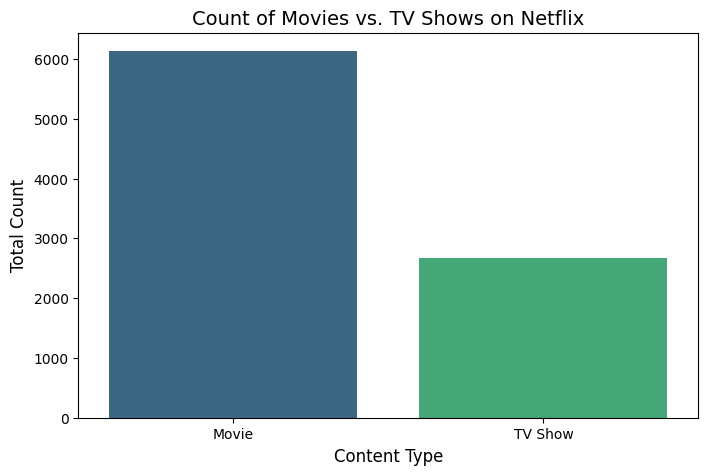

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='type', palette='viridis')
plt.title('Count of Movies vs. TV Shows on Netflix', fontsize=14)
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.show()

Line Chart

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

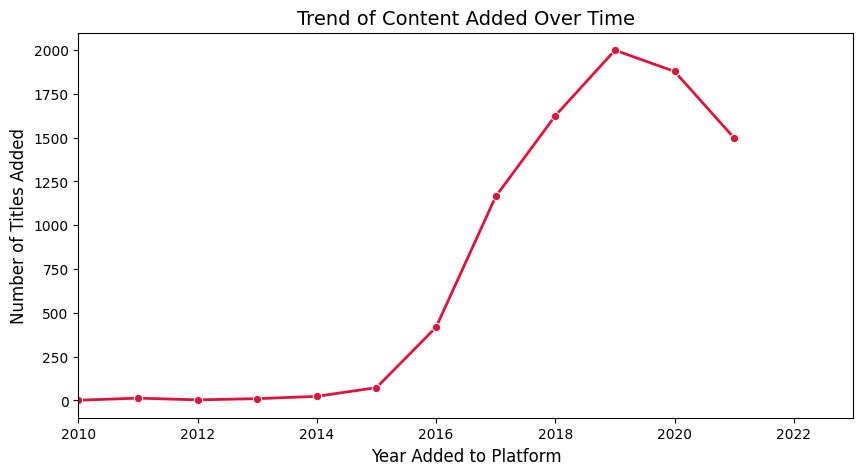

In [ ]:
plt.figure(figsize=(10, 5))
# Group by the year added and count the titles
content_trend = df.groupby('year_added').size()
sns.lineplot(x=content_trend.index, y=content_trend.values, marker='o', color='crimson', linewidth=2)
plt.title('Trend of Content Added Over Time', fontsize=14)
plt.xlabel('Year Added to Platform', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.xlim(2010, 2023) # Zooming in on the active years for better readability
plt.show()

Histogram

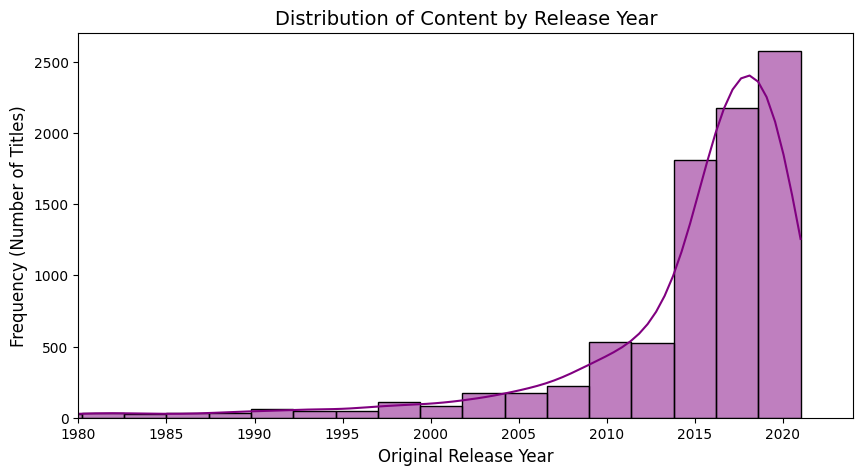

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['release_year'], bins=40, kde=True, color='purple')
plt.title('Distribution of Content by Release Year', fontsize=14)
plt.xlabel('Original Release Year', fontsize=12)
plt.ylabel('Frequency (Number of Titles)', fontsize=12)
plt.xlim(1980, 2024) # Excluding very old outliers to keep the chart readable
plt.show()

Pie Chart

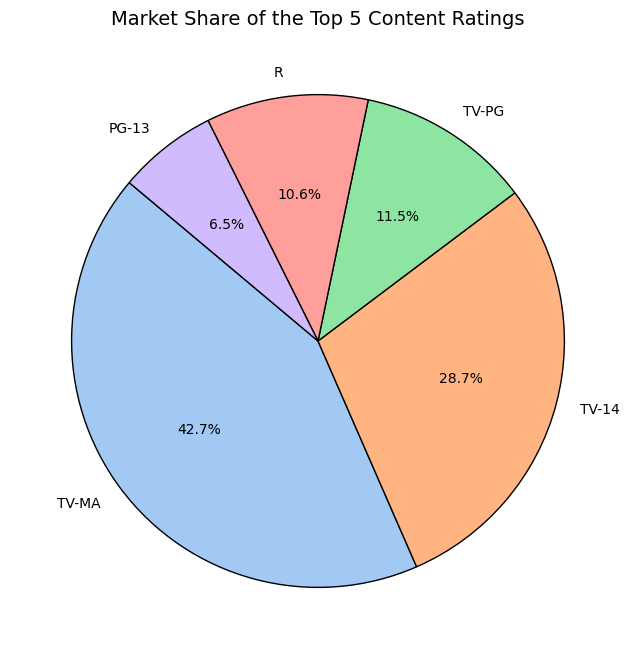

In [ ]:
plt.figure(figsize=(8, 8))

top_ratings = df['rating'].value_counts().head(5)
plt.pie(top_ratings, labels=top_ratings.index, autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})
plt.title('Market Share of the Top 5 Content Ratings', fontsize=14)
plt.show()

HEATMAP: Correlation between Numeric Variables

In [ ]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min', '').astype(float)


sns.set_theme(style="whitegrid")

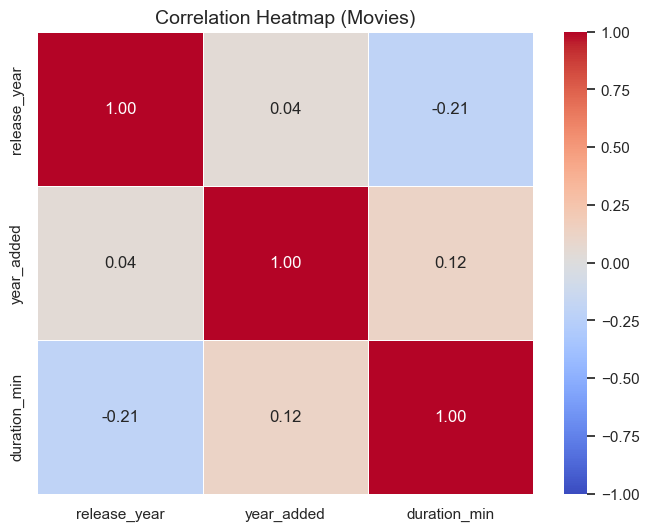

In [ ]:
plt.figure(figsize=(8, 6))
# Select only the numeric columns from our movies dataset
numeric_cols = movies[['release_year', 'year_added', 'duration_min']].dropna()
# Calculate the correlation matrix
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Movies)', fontsize=14)
plt.show()

Scatter Plot

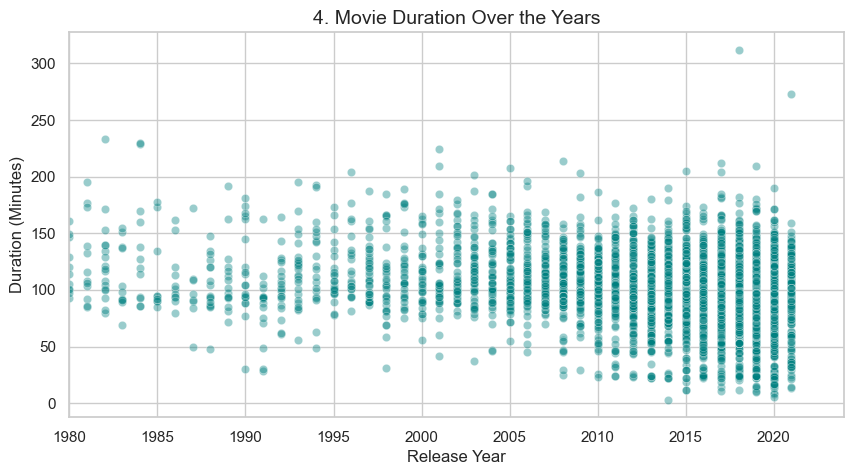

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=movies, x='release_year', y='duration_min', alpha=0.4, color='teal')
plt.title('4. Movie Duration Over the Years', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Duration (Minutes)', fontsize=12)
plt.xlim(1980, 2024)
plt.show()